## Assignment: Transfer Learning on the Caltech-256 Dataset (20 Marks)
# Question 1: Dataset Loading and Preprocessing (3 Marks)

a) Load the Caltech-256 dataset for multi-class image classification.

b) Apply suitable image transformations, including resizing and normalization, to prepare the dataset for training.

c) Create training, validation, and test data loaders with appropriate batch size and shuffling strategy.

# Question 2: Data Visualization and Distribution Analysis (3 Marks)

a) Plot the class-wise distribution of samples in the dataset.

b) Display a fixed number of sample images (e.g., four) from different classes along with their class labels.

# Question 3: Baseline CNN Model (4 Marks)

a) Design and implement a baseline Convolutional Neural Network trained from scratch for multi-class classification.

b) Select an appropriate loss function and optimizer for training the CNN.
Justify your choices for this classification task.

# Question 4: Transfer Learning Models (3 Marks)

a) Implement a transfer learning model using a pretrained CNN (your choice) with the backbone frozen and a newly initialized classification head.

b) Implement another transfer learning model with partial fine-tuning of the pretrained backbone.Describe how partial fine-tuning differs from full freezing and when it is beneficial.

# Question 5: Training, Evaluation, and Analysis (5 Marks)

a) Train all three models (CNN from scratch, frozen-backbone model, partially fine-tuned model) and analyze their training behavior.

b) Evaluate the models using suitable metrics such as accuracy and F1-score.
Briefly discuss which model performs best and why.

# Question 6: Conceptual Understanding(2 marks)

Why is transfer learning effective for large multi-class datasets like Caltech-256?

What are the main limitations of transfer learning when dataset classes differ significantly from the pretrained dataset?

In [ ]:
# =========================
# Q1: Dataset Loading & Preprocessing
# =========================
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

data_dir = "./caltech256"
batch_size = 32

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = datasets.ImageFolder(
    root=data_dir,
    transform=transform
)

train_size = int(0.7 * len(dataset))
val_size   = int(0.15 * len(dataset))
test_size  = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(
    dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

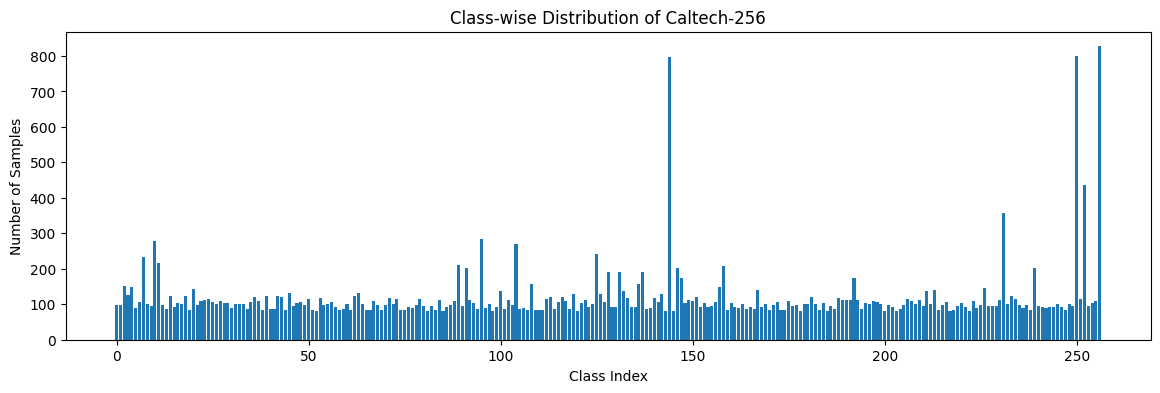

In [ ]:
# =========================
# Q2a: Class-wise Distribution
# =========================
import matplotlib.pyplot as plt
from collections import Counter

labels = [label for _, label in dataset.samples]
class_counts = Counter(labels)

plt.figure(figsize=(14, 4))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Class Index")
plt.ylabel("Number of Samples")
plt.title("Class-wise Distribution of Caltech-256")
plt.show()

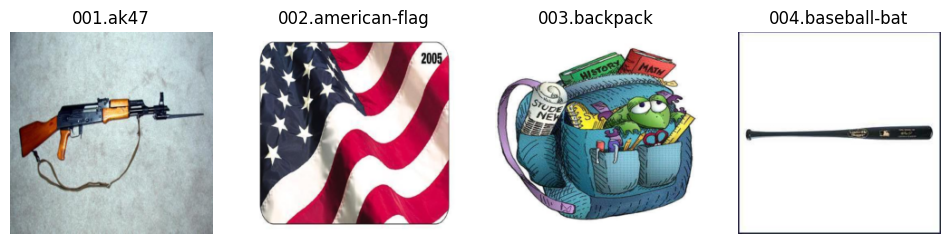

In [ ]:
# =========================
# Q2b: Sample Images Visualization
# =========================
import numpy as np
import matplotlib.pyplot as plt

# Separate transform for visualization (NO normalization)
viz_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

viz_dataset = datasets.ImageFolder(
    root=data_dir,
    transform=viz_transform
)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
shown_classes = set()
idx = 0

for img, label in viz_dataset:
    if label not in shown_classes:
        shown_classes.add(label)

        # Handle grayscale images
        if img.shape[0] == 1:
            img = img.repeat(3, 1, 1)

        img = img.permute(1, 2, 0).numpy()

        axes[idx].imshow(img)
        axes[idx].set_title(viz_dataset.classes[label])
        axes[idx].axis("off")
        idx += 1

    if idx == 4:
        break

plt.show()

In [ ]:
# =========================
# Q3: Baseline CNN Model (From Scratch)
# =========================
import torch.nn as nn
import torch.nn.functional as F

num_classes = 257

class SimpleCNN(nn.Module):
  def __init__(self, num_classes):
    super().__init__()
    self.features = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128 * 28 * 28, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )

  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x

baseline_model = SimpleCNN(num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=1e-3)

In [ ]:
# =========================
# Q4a: Transfer Learning (Frozen Backbone)
# =========================
from torchvision import models

resnet_frozen = models.resnet18(pretrained=True)

for param in resnet_frozen.parameters():
    param.requires_grad = False

resnet_frozen.fc = nn.Linear(resnet_frozen.fc.in_features, num_classes)

criterion = nn.CrossEntropyLoss()
optimizer_frozen = torch.optim.Adam(resnet_frozen.fc.parameters(), lr=1e-3)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 221MB/s]


In [ ]:
# =========================
# Q4b: Transfer Learning (Partial Fine-tuning)
# =========================
resnet_partial = models.resnet18(pretrained=True)

for name, param in resnet_partial.named_parameters():
    if "layer4" not in name:
        param.requires_grad = False

resnet_partial.fc = nn.Linear(resnet_partial.fc.in_features, num_classes)

optimizer_partial = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet_partial.parameters()),
    lr=1e-4
)

In [ ]:
# =========================
# Q5: Training & Evaluation
# =========================
from sklearn.metrics import accuracy_score, f1_score

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0.0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

def evaluate_with_loss(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            loss = criterion(outputs, labels)
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, acc, f1

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=5):
    model.to(device)

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": []
    }

    for epoch in range(epochs):
        train_loss = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )

        val_loss, val_acc, val_f1 = evaluate_with_loss(
            model, val_loader, criterion, device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val F1: {val_f1:.4f}"
        )

    return history

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Baseline CNN
history_cnn = train_model(
    baseline_model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=10
)

Epoch [1/10] Train Loss: 4.5750 | Val Loss: 4.3777 | Val Acc: 0.1507 | Val F1: 0.0525
Epoch [2/10] Train Loss: 4.0981 | Val Loss: 4.1013 | Val Acc: 0.1856 | Val F1: 0.0995
Epoch [3/10] Train Loss: 3.4525 | Val Loss: 4.0367 | Val Acc: 0.2115 | Val F1: 0.1306
Epoch [4/10] Train Loss: 2.6221 | Val Loss: 4.1547 | Val Acc: 0.2119 | Val F1: 0.1349
Epoch [5/10] Train Loss: 1.8809 | Val Loss: 4.3848 | Val Acc: 0.2037 | Val F1: 0.1360
Epoch [6/10] Train Loss: 1.3666 | Val Loss: 4.7795 | Val Acc: 0.2039 | Val F1: 0.1385
Epoch [7/10] Train Loss: 1.0453 | Val Loss: 4.9999 | Val Acc: 0.2074 | Val F1: 0.1453
Epoch [8/10] Train Loss: 0.8353 | Val Loss: 5.3801 | Val Acc: 0.1971 | Val F1: 0.1340
Epoch [9/10] Train Loss: 0.7197 | Val Loss: 5.6549 | Val Acc: 0.2032 | Val F1: 0.1389
Epoch [10/10] Train Loss: 0.6217 | Val Loss: 5.7858 | Val Acc: 0.1978 | Val F1: 0.1358


In [ ]:
# Frozen-backbone ResNet
history_frozen = train_model(
    resnet_frozen,
    train_loader,
    val_loader,
    optimizer_frozen,
    criterion,
    device,
    epochs=10
)

Epoch [1/10] Train Loss: 2.2662 | Val Loss: 1.1329 | Val Acc: 0.7395 | Val F1: 0.7205
Epoch [2/10] Train Loss: 0.9126 | Val Loss: 0.9766 | Val Acc: 0.7508 | Val F1: 0.7338
Epoch [3/10] Train Loss: 0.6856 | Val Loss: 0.9136 | Val Acc: 0.7711 | Val F1: 0.7556
Epoch [4/10] Train Loss: 0.5637 | Val Loss: 0.8959 | Val Acc: 0.7763 | Val F1: 0.7562
Epoch [5/10] Train Loss: 0.4720 | Val Loss: 0.9186 | Val Acc: 0.7704 | Val F1: 0.7521
Epoch [6/10] Train Loss: 0.4131 | Val Loss: 0.8947 | Val Acc: 0.7780 | Val F1: 0.7663
Epoch [7/10] Train Loss: 0.3643 | Val Loss: 0.9316 | Val Acc: 0.7702 | Val F1: 0.7513
Epoch [8/10] Train Loss: 0.3297 | Val Loss: 0.9222 | Val Acc: 0.7767 | Val F1: 0.7587
Epoch [9/10] Train Loss: 0.2867 | Val Loss: 0.9243 | Val Acc: 0.7796 | Val F1: 0.7633
Epoch [10/10] Train Loss: 0.2620 | Val Loss: 0.9642 | Val Acc: 0.7717 | Val F1: 0.7540


In [ ]:
# Partially fine-tuned ResNet
history_partial = train_model(
    resnet_partial,
    train_loader,
    val_loader,
    optimizer_partial,
    criterion,
    device,
    epochs=10
)

Epoch [1/10] Train Loss: 2.7532 | Val Loss: 1.4468 | Val Acc: 0.7227 | Val F1: 0.6838
Epoch [2/10] Train Loss: 1.0431 | Val Loss: 0.9797 | Val Acc: 0.7874 | Val F1: 0.7661
Epoch [3/10] Train Loss: 0.5176 | Val Loss: 0.8826 | Val Acc: 0.8014 | Val F1: 0.7834
Epoch [4/10] Train Loss: 0.2273 | Val Loss: 0.8184 | Val Acc: 0.8146 | Val F1: 0.7976
Epoch [5/10] Train Loss: 0.0874 | Val Loss: 0.8071 | Val Acc: 0.8105 | Val F1: 0.7942
Epoch [6/10] Train Loss: 0.0394 | Val Loss: 0.7799 | Val Acc: 0.8177 | Val F1: 0.8000
Epoch [7/10] Train Loss: 0.0226 | Val Loss: 0.7748 | Val Acc: 0.8225 | Val F1: 0.8045
Epoch [8/10] Train Loss: 0.0160 | Val Loss: 0.7939 | Val Acc: 0.8177 | Val F1: 0.8001
Epoch [9/10] Train Loss: 0.0189 | Val Loss: 0.8031 | Val Acc: 0.8146 | Val F1: 0.7968
Epoch [10/10] Train Loss: 0.0138 | Val Loss: 0.9161 | Val Acc: 0.7946 | Val F1: 0.7792


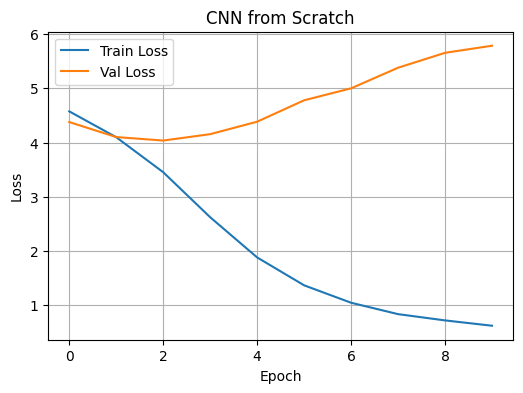

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history_cnn["train_loss"], label="Train Loss")
plt.plot(history_cnn["val_loss"], label="Val Loss")
plt.title("CNN from Scratch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

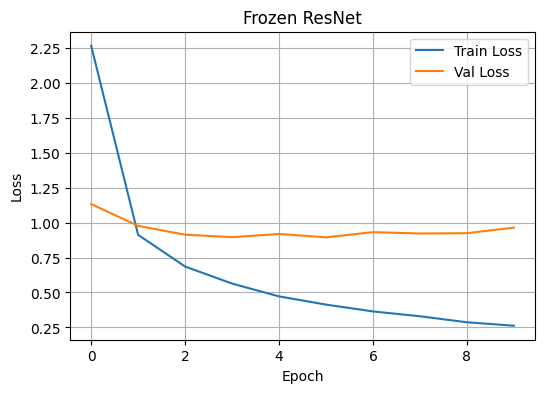

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history_frozen["train_loss"], label="Train Loss")
plt.plot(history_frozen["val_loss"], label="Val Loss")
plt.title("Frozen ResNet")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

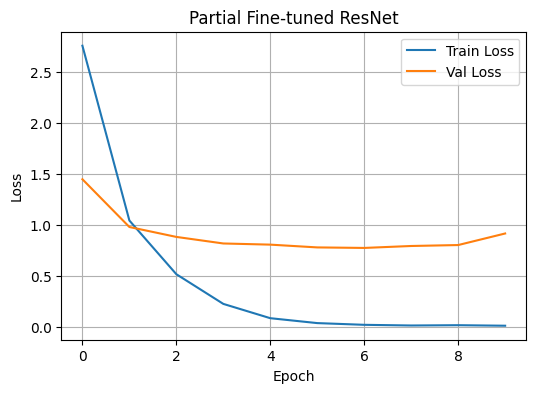

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history_partial["train_loss"], label="Train Loss")
plt.plot(history_partial["val_loss"], label="Val Loss")
plt.title("Partial Fine-tuned ResNet")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
models = {
    "CNN from Scratch": baseline_model,
    "Frozen ResNet": resnet_frozen,
    "Partial Fine-tuned ResNet": resnet_partial
}

for name, model in models.items():
    acc, f1 = evaluate(model, test_loader, device)
    print(f"{name} → Test Accuracy: {acc:.4f}, Test F1: {f1:.4f}")

CNN from Scratch → Test Accuracy: 0.2025, Test F1: 0.1363
Frozen ResNet → Test Accuracy: 0.7814, Test F1: 0.7629
Partial Fine-tuned ResNet → Test Accuracy: 0.7992, Test F1: 0.7794


# =========================
# Q6: Conceptual Answers
# =========================
Transfer learning is effective because pretrained models learn more general-purpose
visual features from large datasets, which transfer well to new
multi-class tasks like Caltech-256, reducing training time and data requirements.

Limitations : negative transfer when target classes differ significantly
from pretrained data, overfitting on small datasets, and reduced flexibility if
important layers are frozen.